# Import Libraries

In [928]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, classification_report
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif


In [929]:
pd.set_option("display.max_columns", None)


# Load data

In [1005]:
bank_df = pd.read_csv("bank-marketing-dataset-full.csv", sep=";")
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [931]:
samples, features = bank_df.shape
print(f"The dataset contains {samples} sampled and {features} features ")

The dataset contains 41188 sampled and 21 features 


In [932]:
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# EDA
- Check missing values
- Understand feature ranges and distribution
- Examin pairwise correlation

In [933]:
bank_df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

There are no Missing data, however missing data are labeled as "unknown"

In [934]:
print(f"'unknown' in each features")
missing = []
for col in bank_df.columns:
    unknown_count = bank_df[bank_df[col] == 'unknown'][col].value_counts()
    if unknown_count.values.size>0:
        missing.append({"Feature": col, "feature_type": bank_df[col].dtypes, "ncount": unknown_count.values[0], "percentage": round((unknown_count.values[0]/samples)*100, 2)})
        #print(f"feature: {col}, feature_type: {bank_df[col].dtypes}: \ncount: {unknown_count.values[0]}, percentage: {round((unknown_count.values[0]/samples)*100, 2)}%")
pd.DataFrame(missing)



'unknown' in each features


,Feature,feature_type,ncount,percentage
0,job,str,330,0.80
1,marital,str,80,0.19
2,education,str,1731,4.20
3,default,str,8597,20.87
4,housing,str,990,2.40
5,loan,str,990,2.40


Unknown percentage is less than 50%, so descided not to drop the feature, instead will impute with appropriate data.

In [935]:
bank_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [936]:
bank_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [937]:
#No of duplicate row
print(f"No of duplicated rows: {bank_df.duplicated().sum()}")

No of duplicated rows: 12


In [938]:
# drop duplicates:

bank_df.drop_duplicates(inplace=True)
bank_df.shape

(41176, 21)

In [939]:
bank_df["y"] = bank_df["y"].map({'yes': 1, 'no':0})

In [940]:
object_cols = bank_df.select_dtypes("str").columns.to_list()
number_cols = bank_df.select_dtypes(["int64", "float64"]).columns.to_list()

print(f"Object Columns: {object_cols}")
print(f"Numeric Columns: {number_cols}")
print(f"Number of object columns: {len(object_cols)}, number of number columns: {len(number_cols)}")

Object Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric Columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Number of object columns: 10, number of number columns: 11


In [941]:
bank_df[bank_df["y"] == 1].head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
75,41,blue-collar,divorced,basic.4y,unknown,yes,no,telephone,may,mon,1575,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,1
83,49,entrepreneur,married,university.degree,unknown,yes,no,telephone,may,mon,1042,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,1
88,49,technician,married,basic.9y,no,no,no,telephone,may,mon,1467,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,1
129,41,technician,married,professional.course,unknown,yes,no,telephone,may,mon,579,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,1
139,45,blue-collar,married,basic.9y,unknown,yes,no,telephone,may,mon,461,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,1


### Distribution of numeric features

In [942]:
def numeric_distribution_plot(df, target):
    fig, axes = plt.subplots(11,2, figsize = (16,50))

    for i, col in enumerate(df.columns.to_list()):
        feature_mean = df[col].mean()
        feature_median = df[col].median()

        sns.histplot(df, x= col, hue=target,  ax=axes[i][0])
        axes[i][0].axvline(feature_mean, color='red', linestyle='--', label=f"Mean: {feature_mean}")
        axes[i][0].axvline(feature_median, color='green', linestyle='-', label=f"Median: {feature_median}")
        axes[i][0].set_title(f"'{col}' feature Distribution")
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel("Frequency")
        axes[i][0].legend()

        #sns.boxplot(df[col], ax=axes[i][1])

        sns.boxplot(data=df, x=target, y=col, ax=axes[i][1])
        
        axes[i][1].set_title(f"Boxplot of '{col}'")
        #axes[i][1].set_xlabel(col)


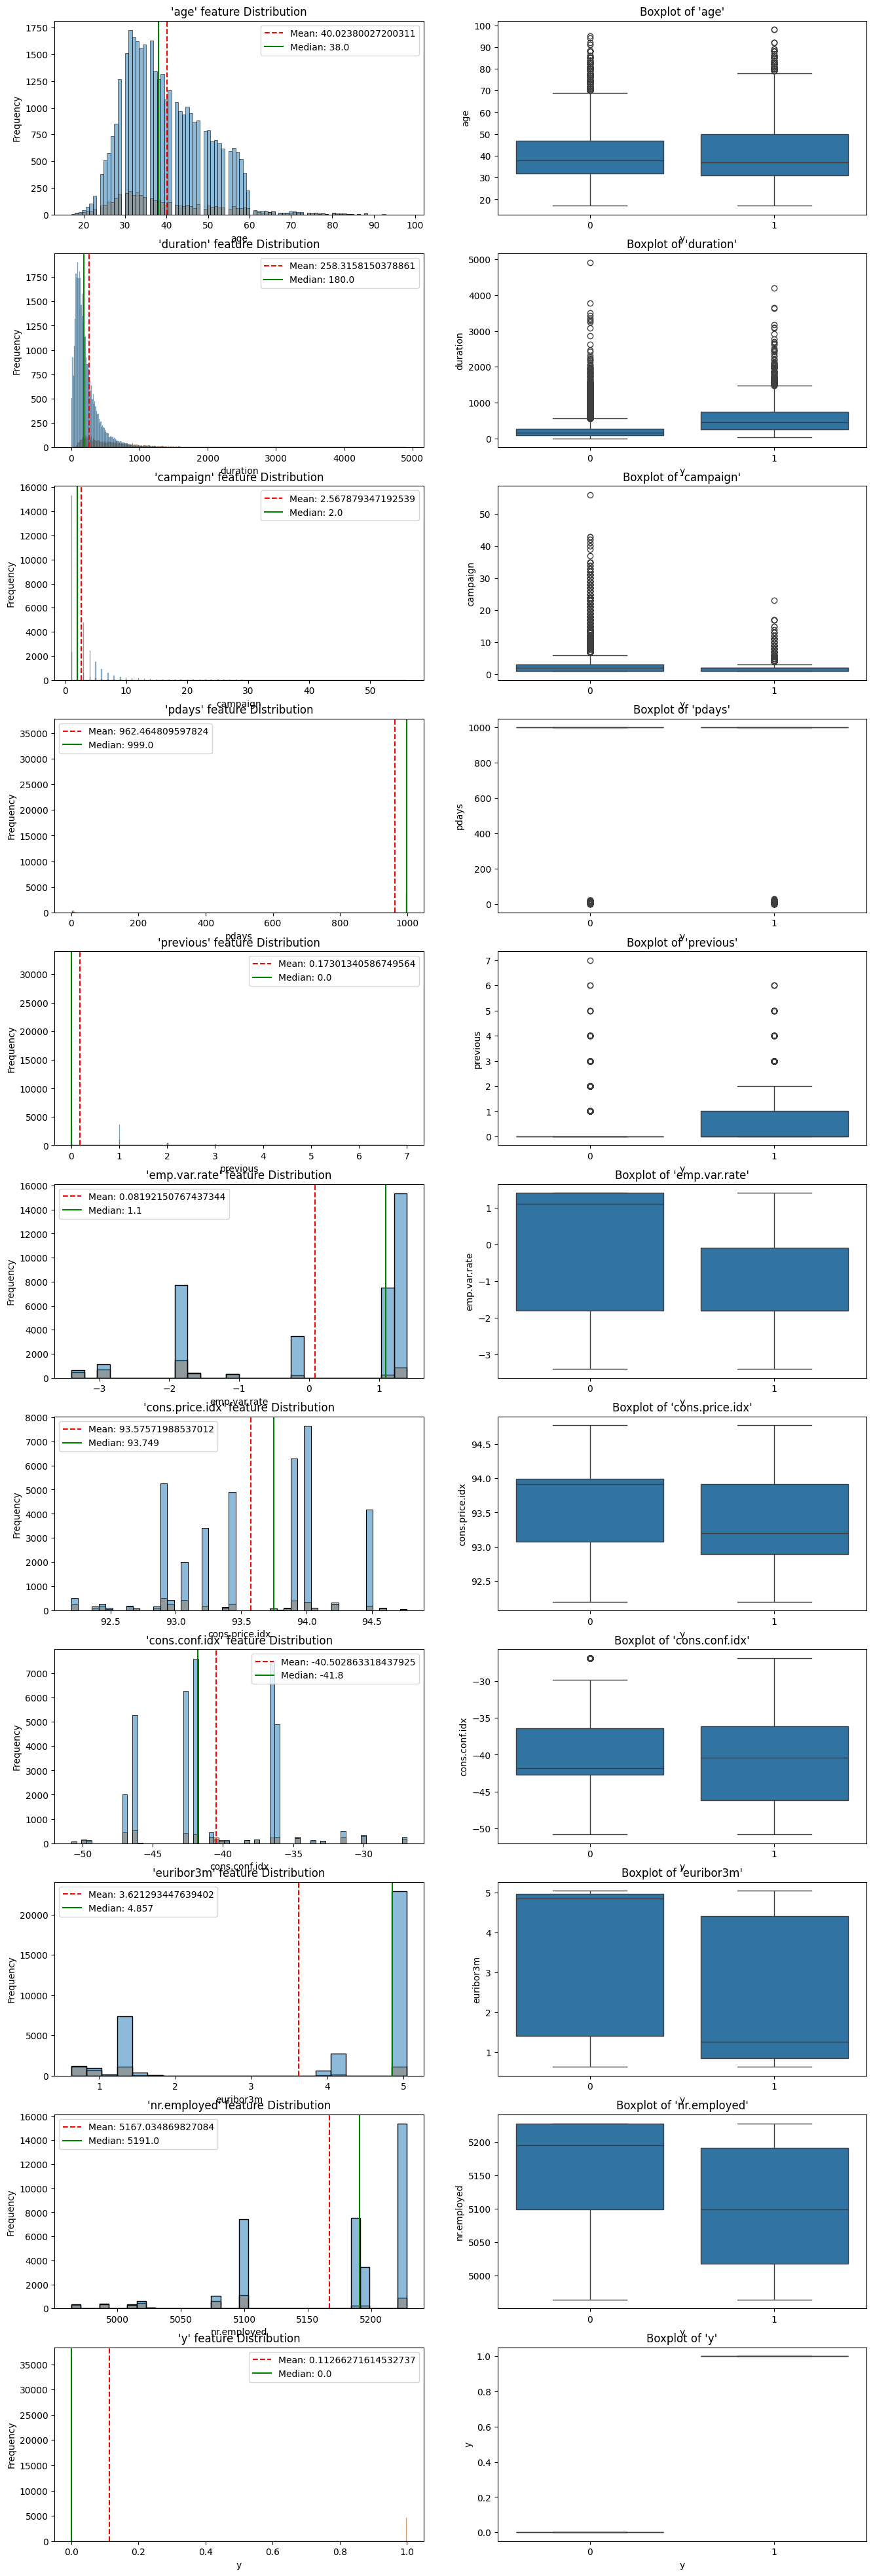

In [943]:
numeric_distribution_plot(bank_df[number_cols], bank_df['y'])

In [ ]:
# # skewness

# from statistics import quantiles

# numeric_cols = ['age', 'duration', 'campaign', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
# # 'pdays', 'previous',

# for col in numeric_cols:
#     q1, q2, q3 = quantiles(bank_df[col])
#     skb = (q1+q3-2*q2) / (q3 - q1)
#     print(f"{col}: {round(skb, 3)}")
#     if abs(skb) > 0.5:
#         print(f"{col} is skewed\n")
#     else:
#         print(f"{col} is symmetric\n")

age: 0.2
age is symmetric

duration: 0.281
duration is symmetric

campaign: 0.0
campaign is symmetric

emp.var.rate: -0.813
emp.var.rate is skewed

cons.price.idx: -0.467
cons.price.idx is symmetric

cons.conf.idx: 0.714
cons.conf.idx is skewed

euribor3m: -0.942
euribor3m is skewed

nr.employed: -0.425
nr.employed is symmetric



Skewness: 
Highly skewed : 'emp.var.rate', cons.conf.idx', 'euribor3m',
Symmetric: 'age', 'duration', 'campaign', 'cons.price.idx', 'nr.employed'

If customer is never contacted then ‘Pdays’ is marked as 999 and ‘previous’ as 0. Create a new boolean feature __was_customer_contact__ (yes/no) to better specify this situation.

### Outlier counts

In [1045]:
numeric_cols = ['age', 'duration', 'pdays', 'previous', 'campaign', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
# 

def count_outliers(col):
    q1, q3 = col.quantile([0.25, 0.75])
    iqr = q3-q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    return ((col<lower) | (col > upper)).sum()

outlier_df = (bank_df[numeric_cols]
            .apply(count_outliers)).reset_index()\
            .rename(columns={"index": "Feature", 0: "Count"})\
            .sort_values(by="Count", ascending=False)

outlier_df

,Feature,Count
3,previous,5625
1,duration,2963
4,campaign,2406
2,pdays,1515
0,age,469
7,cons.conf.idx,447
5,emp.var.rate,0
6,cons.price.idx,0
8,euribor3m,0
9,nr.employed,0


In [945]:
# for col in number_cols:
#     plt.figure(figsize=(5,4))
#     sns.boxplot(data=bank_df[number_cols], x="y", y=col)
#     plt.title(f"{col} vs Target")
#     plt.show()

### Distribution of categorical features

In [946]:
def object_distribution_plot(df):
    fig, axes = plt.subplots(6,2, figsize = (24,30))
    axes = axes.flatten()

    for i, col in enumerate(df.columns.to_list()):
        count = df[col].value_counts()
        
        axes[i].bar(count.index, count.values)
        #axes[i].bar_label(axes[i].containers[0], fontsize=10)
        
        total = sum(count.values)
        for container in axes[i].containers:
            labels = [f"{(h/total)*100: .1f}%" for h in container.datavalues]
            axes[i].bar_label(container, labels=labels, fontsize=10)
        
        axes[i].set_title(f"'{col}' feature Distribution")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(len(df.columns.to_list()), len(axes)):
        axes[j].set_visible(False)

In [947]:
target = ["y"]
#object_distribution_plot(bank_df[object_cols+target])

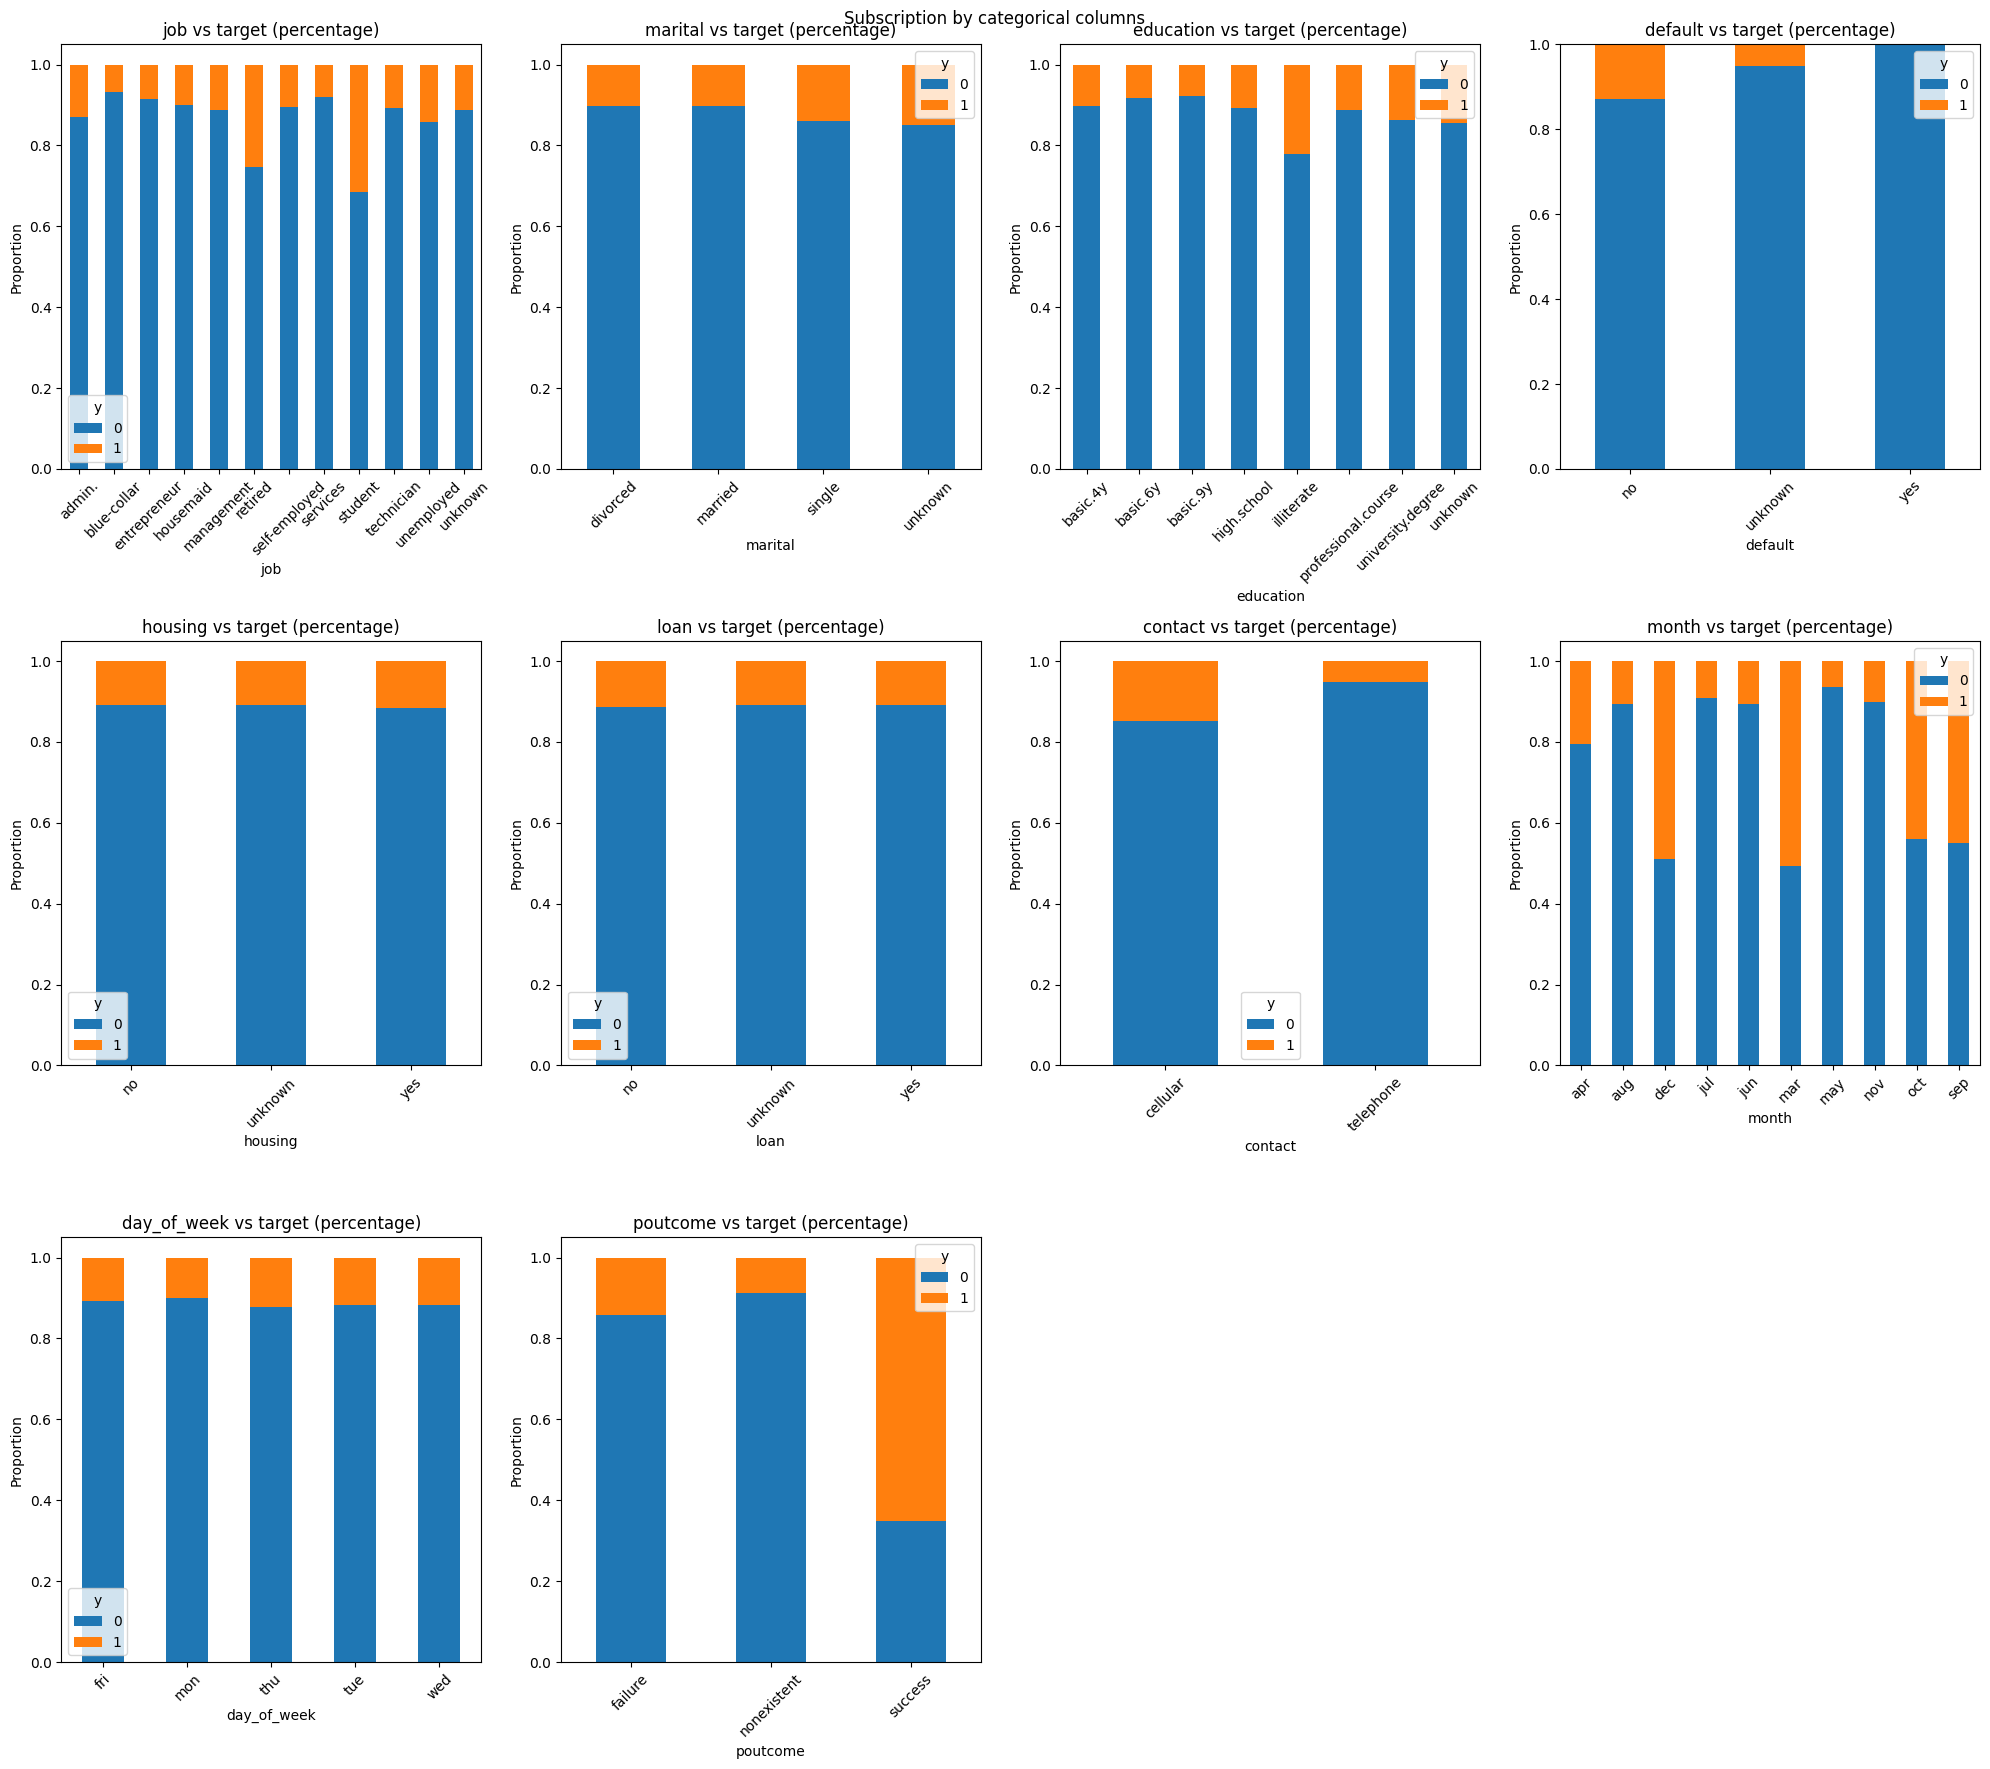

In [948]:
fig, axes = plt.subplots(3,4, figsize = (20,18))
axes = axes.flatten()

for i, col in enumerate(object_cols):
    ct = pd.crosstab(bank_df[col], bank_df['y'], normalize='index')

    ct.plot(kind='bar', stacked=True, ax = axes[i])
    axes[i].set_title(f"{col} vs target (percentage)")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis ='x', rotation=45)

for j in range(len(object_cols), len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle("Subscription by categorical columns")
plt.tight_layout()
plt.show()

<Axes: xlabel='job'>

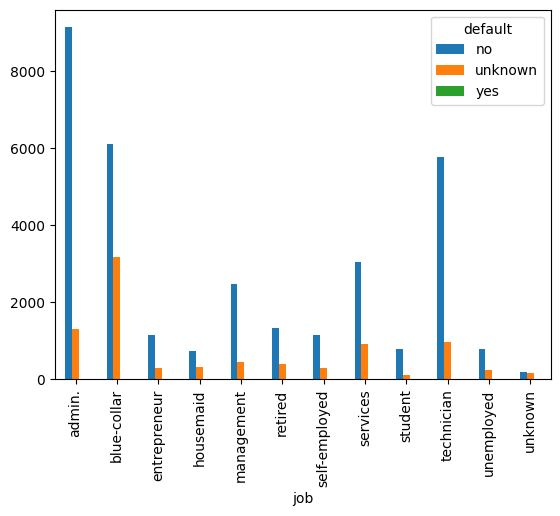

In [949]:
ct = bank_df.groupby(["job", "default"])["y"].count()
ct_unstacked = ct.unstack()
ct_unstacked.plot(kind='bar')


Target Distribution is imbalance.

### Bivariate analysis

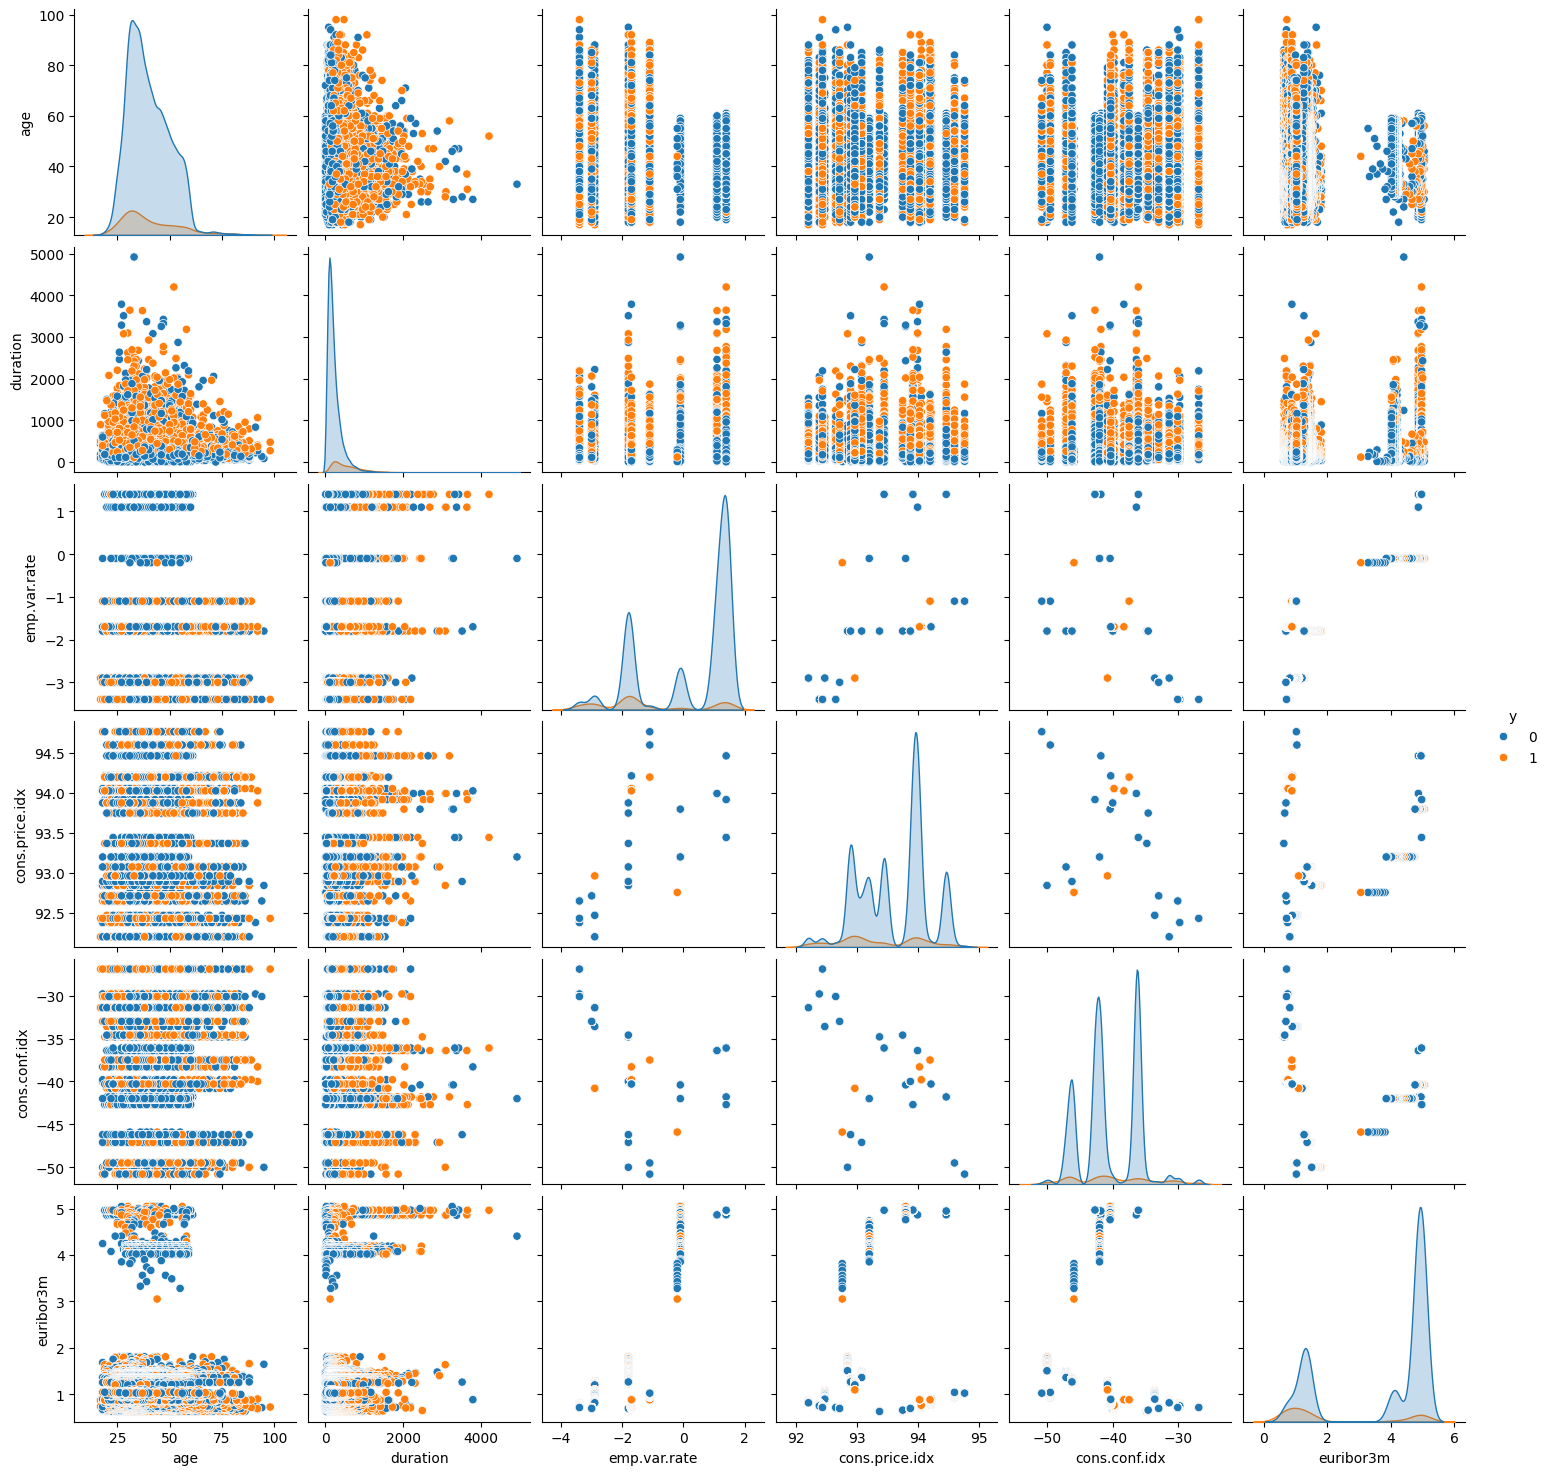

In [950]:
sns.pairplot(bank_df[["age","duration", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "y"]], hue="y")

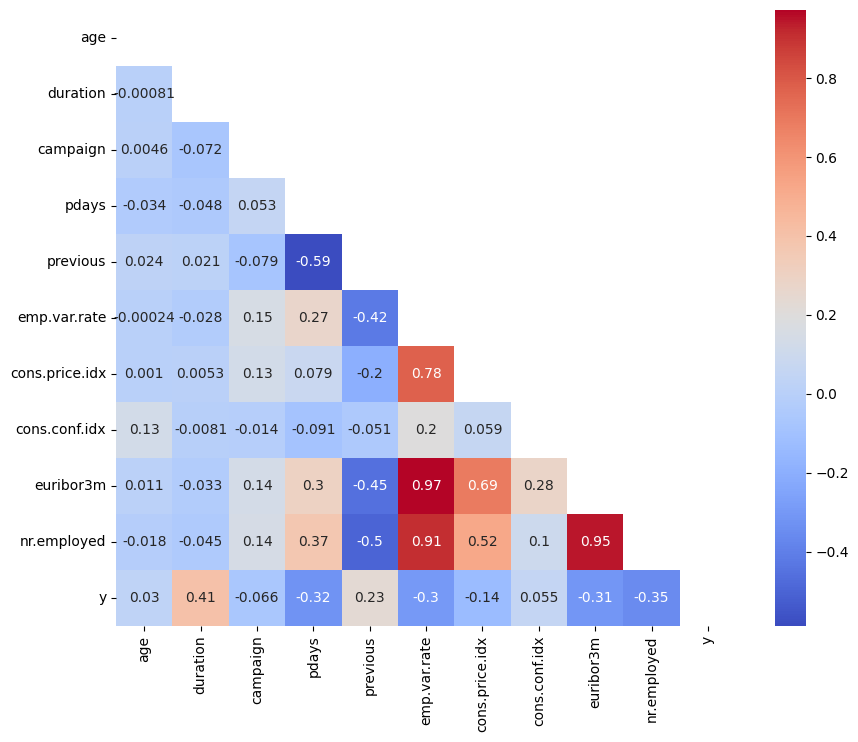

In [951]:
corr = bank_df[number_cols].corr()
plt.figure(figsize=(10,8))

mask = np.triu(np.ones_like(corr, dtype=bool))  
sns.heatmap(corr, mask= mask, cmap='coolwarm', annot=True)
plt.show()


In [986]:
# Column 'pdays' - 96% of the data is 999(not contacted)
bank_df["was_contacted_before"] = (bank_df["pdays"] == 999).astype('int')
bank_df.drop(columns=["pdays"], inplace=True)
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted_before
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,1


# Hypothesis testing



### Welch's t-test Numerical columns

check if mean of the numerical variables differs significantly between subscription 'yes' and 'no' 

H0: The mean of the variable is same for subscribed and not subscribed customers.

Ha: The mean of the variable is not same for subscribed and not subscribed customers.

In [988]:
from scipy import  stats

alpha = 0.05

numeric_cols = ['age', 'duration', 'campaign', 'was_contacted_before', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

subscribed = bank_df[bank_df["y"] == 1]
not_subscribed = bank_df[bank_df["y"] == 0]

ttest_results = []

for col in numeric_cols:
    grouped_subscribed = subscribed[subscribed[col] != 'unknown'][col]
    grouped_not_subscribed = not_subscribed[not_subscribed[col] != 'unknown'][col]

    t_stat, p_value = stats.ttest_ind(grouped_subscribed, grouped_not_subscribed, equal_var=False)
    ttest_results.append({
        "col": col,
        "subscribed mean": round(grouped_subscribed.mean(),2),
        "Not subscribed mean": round(grouped_not_subscribed.mean(),2),
        "t_stat": round(t_stat, 4),
        "p_value": round(p_value, 8),
        "Reject H0": 'yes' if p_value < alpha else "No"
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df

,col,subscribed mean,Not subscribed mean,t_stat,p_value,Reject H0
0,age,40.91,39.91,4.7753,0.000002,yes
1,duration,553.26,220.87,55.4984,0.000000,yes
2,campaign,2.05,2.63,-20.2479,0.000000,yes
3,was_contacted_before,0.79,0.99,-32.2510,0.000000,yes
4,previous,0.49,0.13,28.1256,0.000000,yes
5,emp.var.rate,-1.23,0.25,-59.1166,0.000000,yes
6,cons.price.idx,93.35,93.60,-24.0670,0.000000,yes
7,cons.conf.idx,-39.79,-40.59,8.6227,0.000000,yes
8,euribor3m,2.12,3.81,-62.5603,0.000000,yes
9,nr.employed,5095.12,5176.17,-60.9589,0.000000,yes


T-test hypothesis testing on numerical features shows that there is significant difference in the mean of each feature between subscribed and not subscribed consumers.


### Chi-test for categorical columns
- H0: The categorical variable and subscription are independent
- H1: The categorical variable and subscription are not independent

In [953]:
from scipy import stats


alpha = 0.05

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


chi_test_results = []

for col in categorical_cols:
    #bank_df_subset = bank_df[bank_df[col] != 'unknown']
    contingency_table = pd.crosstab(bank_df[col], bank_df["y"])

    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    
    chi_test_results.append({
        "col": col,
        "chi-square Statistics": round(chi2, 4),
        "degree of freedom": dof,
        "p_value": round(p_value, 8),
        "Reject H0": 'yes' if p_value < alpha else "No"
    })

chi_test_results_df = pd.DataFrame(chi_test_results)
chi_test_results_df


,col,chi-square Statistics,degree of freedom,p_value,Reject H0
0,job,961.7438,11,0.000000,yes
1,marital,122.9593,3,0.000000,yes
2,education,192.8485,7,0.000000,yes
3,default,406.5561,2,0.000000,yes
4,housing,5.7422,2,0.056638,No
5,loan,1.0993,2,0.577153,No
6,contact,862.0807,1,0.000000,yes
7,month,3103.0327,9,0.000000,yes
8,day_of_week,26.0542,4,0.000031,yes
9,poutcome,4230.1434,2,0.000000,yes


Chi-test on categorical features shows subscription value strongly dependent on 'job', 'marital', 'education', 'default','contact', 'month', 'day_of_week', 'poutcome' features.

In [954]:
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


# Preprocessing and baseline models

## Train test split

In [993]:
X = bank_df.drop("y", axis=1)
y = bank_df["y"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=9)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32940, 20), (8236, 20), (32940,), (8236,))

In [994]:
df = pd.DataFrame({})
y_train.value_counts(normalize=True)

y
0    0.887341
1    0.112659
Name: proportion, dtype: float64

In [957]:
y_test.value_counts(normalize=True)

y
0    0.887324
1    0.112676
Name: proportion, dtype: float64

## Preprocessing

In [995]:
numeric_cols1 =['age', 'duration', 'campaign', 'previous', 'nr.employed', 'cons.price.idx'] # 'pdays', "month_sin", "month_cos", "day_sin", "day_cos"] # symmetric
numeric_cols2 = ['emp.var.rate', 'cons.conf.idx', 'euribor3m' ] # skewed
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'month', 'day_of_week']
passthrough_cols = ['was_contacted_before']

preporcessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), numeric_cols1),
    ('min_max_scalar', MinMaxScaler(), numeric_cols2),
    ('one_hot_encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ("pass", 'passthrough', passthrough_cols)
])

In [996]:
def extract_feature_names(feature_names: list)->list:
    unique_features = set([feature.split("__")[1].split("_")[0] for feature in feature_names])
    return unique_features

## Baseline models without any feature extraction/ selection

In [997]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, threshold, results):
     pipeline.fit(X_tr, y_tr)
     y_pred_proba_train = pipeline.predict_proba(X_tr)[:,1]
     y_pred_proba_test = pipeline.predict_proba(X_te)[:,1]

     y_pred_train = (y_pred_proba_train > threshold).astype('int')
     y_pred_test = (y_pred_proba_test > threshold).astype('int')
     
     # print(pipeline.predict_proba(X_te)[:10,:])
     # print(y_te.iloc[:10])

     cv_score = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='roc_auc')

     train_accuracy = accuracy_score(y_tr, y_pred_train) #pipeline.score(X_tr, y_tr)
     test_accuracy = accuracy_score(y_te, y_pred_test) # pipeline.score(X_te, y_te)
     
     train_roc_auc = roc_auc_score(y_tr, y_pred_train)
     test_roc_auc = roc_auc_score(y_te, y_pred_test)

     train_precision = precision_score(y_tr, y_pred_train)
     test_precision = precision_score(y_te, y_pred_test)

     results.append({'Model': name,
          'Train Accuracy': train_accuracy,
          'Test Accuracy': test_accuracy,
          'Mean CV Score': f"{cv_score.mean():.3f}",
          'Train ROC-AUC': train_roc_auc,
          'Test ROC-AUC': test_roc_auc,
          'Train Precision': train_precision,
          'Test Precision': test_precision,
          'Train PR-AUC': average_precision_score(y_tr, y_pred_train),
          'Test PR-AUC': average_precision_score(y_te, y_pred_test),
          }
     )
     #print(classification_report(y_te, y_pred_test))
     return pipeline 

In [998]:
results = []
threshold = 0.6
baseline_models = {
    'Logistic Regression': LogisticRegression(C=np.inf, max_iter=2000, random_state=9), # unregularized
    'L1 regularization': LogisticRegression(C=0.5, l1_ratio=1, max_iter=10000, solver='saga', random_state=9),
    'Decision Tree': DecisionTreeClassifier(min_samples_split=10, random_state=9)
}

fitted_pipeline = {}
for name, model in baseline_models.items():
    pipe = Pipeline([('pre', preporcessor), ('model', model)])
    fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, threshold, results)

pd.DataFrame(results)

/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/sumana/Desktop/AIM

,Model,Train Accuracy,Test Accuracy,Mean CV Score,Train ROC-AUC,Test ROC-AUC,Train Precision,Test Precision,Train PR-AUC,Test PR-AUC
0,Logistic Regression,0.908652,0.906387,0.933,0.657632,0.648091,0.697858,0.683841,0.307883,0.292396
1,L1 regularization,0.908804,0.906265,0.933,0.657836,0.646612,0.699605,0.684834,0.308624,0.290859
2,Decision Tree,0.968427,0.898130,0.797,0.888695,0.721521,0.922493,0.553809,0.749004,0.330390


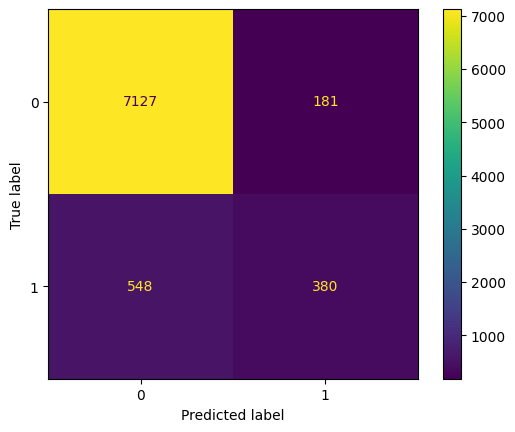

In [962]:
cm = confusion_matrix(y_test, fitted_pipeline["L1 regularization"].predict(X_test))
ConfusionMatrixDisplay(cm).plot()


In [963]:
print(classification_report(y_test, fitted_pipeline["L1 regularization"].predict(X_test)))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7308
           1       0.68      0.41      0.51       928

    accuracy                           0.91      8236
   macro avg       0.80      0.69      0.73      8236
weighted avg       0.90      0.91      0.90      8236



In [964]:
coefs_lr = [abs(x) for x in fitted_pipeline["L1 regularization"].steps[1][1].coef_.round(2).flatten()]
feature_names = list(fitted_pipeline["L1 regularization"][0].get_feature_names_out())
pd.DataFrame(np.column_stack([feature_names, coefs_lr]), columns=["feature", "coef"]).sort_values(by="coef", ascending=True).head(30)

,feature,coef
13,one_hot_encode__job_housemaid,0.0
19,one_hot_encode__job_technician,0.0
20,one_hot_encode__job_unemployed,0.0
22,one_hot_encode__marital_divorced,0.0
23,one_hot_encode__marital_married,0.0
25,one_hot_encode__marital_unknown,0.0
27,one_hot_encode__education_basic.6y,0.0
29,one_hot_encode__education_high.school,0.0
30,one_hot_encode__education_illiterate,0.0
31,one_hot_encode__education_professional.course,0.0


In [965]:
# X_train_encoded = preporcessor.fit_transform(X_train)
# X_test_encoded = preporcessor.transform(X_test)

# lr = LogisticRegression()
# lr.fit(X_train_encoded, y_train)



# print(f"Train accuracy: {lr.score(X_train_encoded, y_train)}")

# print(f"Test accuracy: {lr.score(X_test_encoded, y_test)}")
# print(f"")
# print(classification_report(y_test, lr.predict(X_test_encoded)))


## Baseline models with class imbalance

In [999]:
#results = []
baseline_models = {
    'Logistic Regression - Balanced': LogisticRegression(class_weight='balanced', random_state=9),
    'L1 regularization - Balanced': LogisticRegression(class_weight='balanced', C=0.5, l1_ratio=1, max_iter=10000, solver='saga', random_state=9),
    'Decision Tree - Balanced': DecisionTreeClassifier(class_weight='balanced', min_samples_split=10, random_state=9)
}


for name, model in baseline_models.items():
    pipe = Pipeline([('pre', preporcessor), ('model', model)])
    fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, threshold, results)

pd.DataFrame(results)

,Model,Train Accuracy,Test Accuracy,Mean CV Score,Train ROC-AUC,Test ROC-AUC,Train Precision,Test Precision,Train PR-AUC,Test PR-AUC
0,Logistic Regression,0.908652,0.906387,0.933,0.657632,0.648091,0.697858,0.683841,0.307883,0.292396
1,L1 regularization,0.908804,0.906265,0.933,0.657836,0.646612,0.699605,0.684834,0.308624,0.290859
2,Decision Tree,0.968427,0.898130,0.797,0.888695,0.721521,0.922493,0.553809,0.749004,0.330390
3,Logistic Regression - Balanced,0.878385,0.887203,0.936,0.854426,0.870587,0.476978,0.499683,0.412675,0.441298
4,L1 regularization - Balanced,0.877960,0.886838,0.936,0.854069,0.869441,0.475931,0.498731,0.411715,0.439658
5,Decision Tree - Balanced,0.954038,0.889267,0.787,0.971748,0.795079,0.711861,0.506483,0.708632,0.377902


In [967]:
fitted_pipeline["L1 regularization"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard', ...), ('min_max_scalar', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

### Discover threshold

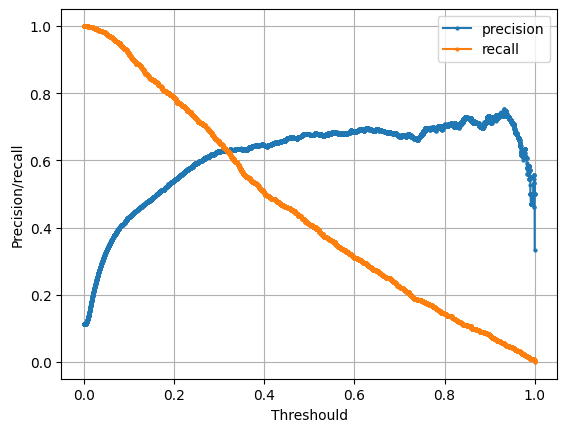

In [968]:
model = fitted_pipeline["L1 regularization"]
y_test_pred_proba = model.predict_proba(X_test)[:,1]
thresholds = np.linspace(0, 1, 10000)
y_precision_list = []
y_recall_list = []
for t in thresholds:
    y_pred = (y_test_pred_proba > t).astype('int')
    precision = precision_score(y_test, y_pred, zero_division=np.nan)
    recall = recall_score(y_test, y_pred, zero_division=np.nan)
    y_precision_list.append(precision)
    y_recall_list.append(recall)

plt.plot(thresholds, y_precision_list, marker ='o', markersize=2, label="precision")
plt.plot(thresholds, y_recall_list, marker ='o', markersize=2, label="recall")
plt.xlabel("Threshould")
plt.ylabel("Precision/recall")
plt.grid(True)
plt.legend()


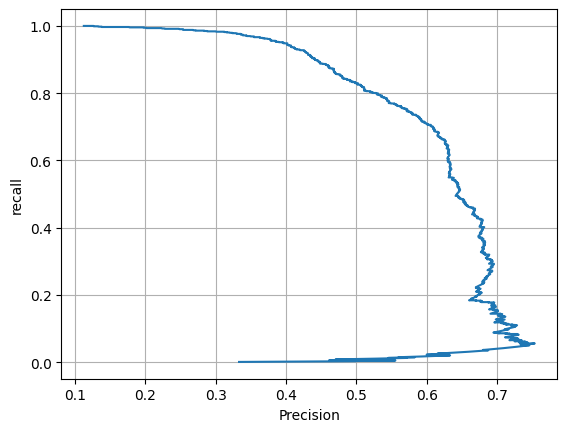

In [969]:
plt.plot(y_precision_list, y_recall_list)
plt.xlabel("Precision")
plt.ylabel("recall")
plt.grid()

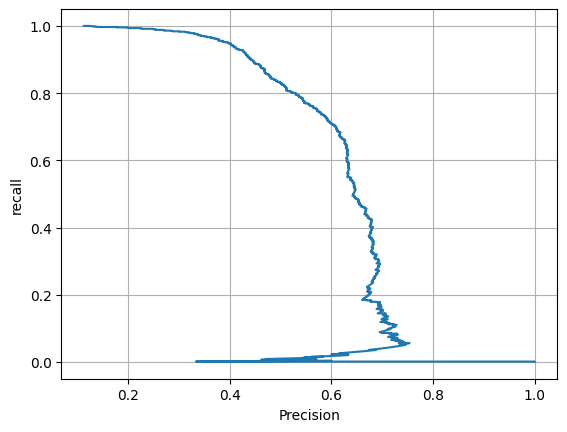

In [970]:
y_pred = model.predict(X_test)
prec, rec, pr_th = precision_recall_curve(y_test, y_test_pred_proba)
plt.plot(prec, rec)
plt.xlabel("Precision")
plt.ylabel("recall")
plt.grid()

In [971]:
len(pr_th)

8236

# Advance Models & Feature Engineering

## Advance Models

In [ ]:
numeric_cols1 =['age', 'duration', 'campaign', 'pdays', 'previous', 'nr.employed', 'cons.price.idx'] # "month_sin", "month_cos", "day_sin", "day_cos"] # symmetric
numeric_cols2 = ['emp.var.rate', 'cons.conf.idx', 'euribor3m' ] # skewed

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'month', 'day_of_week']
passthrough_cols = ['age', 'duration', 'campaign', 'previous', 'nr.employed', 'cons.price.idx', 'emp.var.rate', 'cons.conf.idx', 'euribor3m', "was_contacted_before" ] #'pdays', 

preporcessor = ColumnTransformer(transformers=[
    ('one_hot_encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ("pass", 'passthrough', passthrough_cols)
])

In [1001]:
advance_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, oob_score=True, random_state=9),
    'Random Forest - Balanced': RandomForestClassifier(n_estimators=100, class_weight='balanced', oob_score=True, random_state=9),
    'Adaboost': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=9),
    'Adaboost - Balanced': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'), n_estimators=100,  random_state=9),
    'XGBoost': XGBClassifier(eval_metric='auc', n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
}

#fitted_pipeline = {}
for name, model in advance_models.items():
    pipe = Pipeline([('pre', preporcessor), ('model', model)])
    fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, threshold, results)

pd.DataFrame(results)

,Model,Train Accuracy,Test Accuracy,Mean CV Score,Train ROC-AUC,Test ROC-AUC,Train Precision,Test Precision,Train PR-AUC,Test PR-AUC
0,Logistic Regression,0.908652,0.906387,0.933,0.657632,0.648091,0.697858,0.683841,0.307883,0.292396
1,L1 regularization,0.908804,0.906265,0.933,0.657836,0.646612,0.699605,0.684834,0.308624,0.290859
2,Decision Tree,0.968427,0.898130,0.797,0.888695,0.721521,0.922493,0.553809,0.749004,0.330390
3,Logistic Regression - Balanced,0.878385,0.887203,0.936,0.854426,0.870587,0.476978,0.499683,0.412675,0.441298
4,L1 regularization - Balanced,0.877960,0.886838,0.936,0.854069,0.869441,0.475931,0.498731,0.411715,0.439658
5,Decision Tree - Balanced,0.954038,0.889267,0.787,0.971748,0.795079,0.711861,0.506483,0.708632,0.377902
6,Random Forest,0.998330,0.908572,0.937,0.992590,0.640856,1.000000,0.734584,0.986849,0.296300
7,Random Forest - Balanced,0.998512,0.908694,0.938,0.993398,0.633869,1.000000,0.757310,0.988284,0.292590
8,Adaboost,0.891894,0.890481,0.934,0.528327,0.523416,0.760417,0.696970,0.150886,0.141639
9,Adaboost - Balanced,0.872890,0.878825,0.851,0.698530,0.707350,0.440351,0.463992,0.267807,0.283412


In [974]:
(7169+283)/(7169+283+645+139)

0.9048081593006314

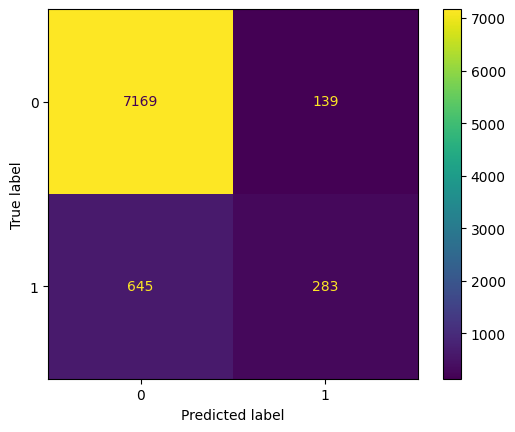

In [975]:
y_pred_proba_test = fitted_pipeline["Adaboost - Balanced"].predict_proba(X_test)[:,1]
y_pred_test = (y_pred_proba_test > 0.7).astype('int')

cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()

## Feature Selection

### variance threshold

In [976]:
from sklearn.feature_selection import VarianceThreshold

X_train_encoded = preporcessor.fit_transform(X_train)
X_test_encoded = preporcessor.transform(X_test)
vt = VarianceThreshold(threshold=0.1)
X_train_vt = vt.fit_transform(X_train_encoded)
X_test_vt = vt.transform(X_test_encoded)

lr = LogisticRegression()
lr.fit(X_train_vt, y_train)

print(f"Variance Threshold - > Kept features: {X_train_vt.shape[1]}")
print(f"Train accuracy: {lr.score(X_train_vt, y_train)}")
print(classification_report(y_test, lr.predict(X_test_vt)))


Variance Threshold - > Kept features: 37
Train accuracy: 0.9101700060716454
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7308
           1       0.67      0.39      0.49       928

    accuracy                           0.91      8236
   macro avg       0.80      0.68      0.72      8236
weighted avg       0.90      0.91      0.90      8236



/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [977]:
(pd.DataFrame(np.column_stack([preporcessor.get_feature_names_out(), vt.variances_]), 
              columns=["Feature", "Variance"])).sort_values(by="Variance", ascending=False).reset_index().drop("index", axis=1).head(19)

,Feature,Variance
0,pass__duration,67509.498042
1,pass__pdays,34610.414377
2,pass__nr.employed,5230.959071
3,pass__age,108.499726
4,pass__cons.conf.idx,21.539272
5,pass__campaign,7.701111
6,pass__euribor3m,3.015316
7,pass__emp.var.rate,2.476328
8,pass__cons.price.idx,0.335305
9,one_hot_encode__housing_yes,0.249435


### embedded method - Lasso

In [978]:
# X_train_encoded = preporcessor.fit_transform(X_train)
# X_test_encoded = preporcessor.transform(X_test)

# lr_l1 = LogisticRegression(C=0.05, l1_ratio=1, solver='saga', random_state=42)
# lr_l1.fit(X_train_encoded, y_train)

# variance = (pd.DataFrame(np.column_stack([preporcessor.get_feature_names_out(), lr_l1.coef_.flatten()]), 
#               columns=["Feature", "Variance"])).sort_values(by="Variance", ascending=False)

# high_variance = variance[~(variance["Variance"] == 0.0)].reset_index(drop=True)
# print(f"L1 logistic regression non-zero features: {high_variance.shape[0]}")
# final_features = set([col.split("__")[1].split("_")[0] for col in high_variance["Feature"].to_list()])
# print(f"L1 logistic regression features count: {len(final_features)} - {final_features}")

### F-test


In [979]:
skb_f = SelectKBest(score_func=f_classif, k=30)

X_tran_encoded = preporcessor.fit_transform(X_train)
X_train_f = skb_f.fit_transform(X_tran_encoded, y_train)
skb_lr = LogisticRegression()
skb_lr.fit(X_train_f, y_train)


print(f"Train cross validation accuracy score: {skb_lr.score(X_train_f, y_train)}")

skb_features_mask = skb_f.get_support()
preporcessor_feature_names = preporcessor.get_feature_names_out()
skb_fatures = preporcessor_feature_names[skb_features_mask]
print(f"F-test selected features: count: {len(extract_feature_names(skb_fatures))}: {extract_feature_names(skb_fatures)}")


Train cross validation accuracy score: 0.9104128718882817
F-test selected features: count: 16: {'emp.var.rate', 'pdays', 'cons.price.idx', 'cons.conf.idx', 'contact', 'job', 'default', 'nr.employed', 'marital', 'campaign', 'duration', 'previous', 'education', 'month', 'poutcome', 'euribor3m'}


/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### With PIpeline

In [980]:
advance_models = {
    'LR + FS-VarianceThreshold': (VarianceThreshold(threshold=0.1), LogisticRegression(class_weight='balanced', random_state=9)),
    'LR + FS-SelectKBest': (SelectKBest(score_func=f_classif, k=30), LogisticRegression(class_weight='balanced', random_state=9)),
    'LR + FS-Mutual Info': (SelectKBest(score_func=mutual_info_classif, k=30), LogisticRegression(class_weight='balanced', random_state=9)),
    #'LR + FS-L1': (None, LogisticRegression(class_weight='balanced', C=0.05, l1_ratio=1, max_iter=5000, solver='saga', random_state=9))
}

#fitted_pipeline = {}
for name, steps in advance_models.items():
    pipe = Pipeline([('pre', preporcessor),('fe', steps[0]),('model', steps[1])])
    fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, threshold, results)

pd.DataFrame(results)


/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/mod

,Model,Train Accuracy,Test Accuracy,Mean CV Score,Train ROC-AUC,Test ROC-AUC,Train Precision,Test Precision,Train PR-AUC,Test PR-AUC
0,Logistic Regression,0.908804,0.906994,0.933,0.658306,0.649844,0.698707,0.689252,0.308956,0.295963
1,L1 regularization,0.908774,0.906144,0.933,0.657818,0.646073,0.699210,0.684086,0.308492,0.290010
2,Decision Tree,0.968822,0.898373,0.799,0.891858,0.726832,0.919637,0.553719,0.752196,0.335574
3,Logistic Regression - Balanced,0.878112,0.887445,0.936,0.853684,0.870724,0.476272,0.500317,0.411604,0.441837
4,L1 regularization - Balanced,0.878112,0.886838,0.936,0.854036,0.868971,0.476294,0.498729,0.411916,0.439241
5,Decision Tree - Balanced,0.954675,0.887445,0.790,0.972343,0.791701,0.714590,0.500404,0.711670,0.371718
6,Random Forest,0.998270,0.909786,0.937,0.992320,0.648596,1.000000,0.735369,0.986371,0.306597
7,Random Forest - Balanced,0.998300,0.906387,0.938,0.992455,0.627865,1.000000,0.730205,0.986610,0.278371
8,Adaboost,0.891682,0.890602,0.934,0.527736,0.523485,0.749129,0.707692,0.149534,0.142170
9,Adaboost - Balanced,0.872890,0.878825,0.851,0.698530,0.707350,0.440351,0.463992,0.267807,0.283412


In [981]:
fitted_pipeline["L1 regularization"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard', ...), ('min_max_scalar', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [982]:


models = [("Baseline", baseline_lr), ("VarianceThreshold", select_threshold_lr), ("SelectKBest", select_k_best), ("MutualInfo", select_mi), ("Lasso", l1_lr)]
for name, pipe in models:
    #feature names
    pipe.fit(X_train, y_train)
    if name == 'Baseline':
        feature_names = pipe.named_steps["pre"].get_feature_names_out()
        unique_selected_features = extract_feature_names(feature_names)
        print(name)
        print(f"Feature count:{len(feature_names)}")
        print(f"Unique feature count: {len(unique_selected_features)}, names: {unique_selected_features}\n")

    elif name == 'VarianceThreshold':
        #get all encoded features
        feature_names = pipe.named_steps["pre"].get_feature_names_out()
        #get mask from variance threshold
        mask = pipe.named_steps["lt_thresh"].get_support()
        selected_features = feature_names[mask]
        unique_selected_features = extract_feature_names(selected_features)

        print(name)
        print(f"Feature count:{len(selected_features)}")
        print(f"Unique feature count: {len(unique_selected_features)},  names: {unique_selected_features}\n")

    elif name == 'SelectKBest':
        skb_features_mask = pipe.named_steps["ftest"].get_support()
        preporcessor_feature_names = pipe.named_steps["pre"].get_feature_names_out()
        skb_fatures = preporcessor_feature_names[skb_features_mask]

        print(name)
        print(f"Features count:{len(skb_fatures)}")
        print(f"Unique feature count:{len(extract_feature_names(skb_fatures))}, names: {extract_feature_names(skb_fatures)}\n")

    elif name == 'MutualInfo':
        skb_features_mask = pipe.named_steps["mi"].get_support()
        preporcessor_feature_names = pipe.named_steps["pre"].get_feature_names_out()
        skb_fatures = preporcessor_feature_names[skb_features_mask]

        print(name)
        print(f"Features count:{len(skb_fatures)}")
        print(f"Unique feature count:{len(extract_feature_names(skb_fatures))}, names: {extract_feature_names(skb_fatures)}\n")


    elif name == 'Lasso':
        feature_names = pipe.named_steps["pre"].get_feature_names_out()
        variance = (pd.DataFrame(np.column_stack([feature_names, pipe.named_steps["lr"].coef_.flatten()]), 
              columns=["Feature", "Variance"])).sort_values(by="Variance", ascending=False)
        
        high_variance = variance[~(variance["Variance"] == 0.0)].reset_index(drop=True)
        unique_selected_features = extract_feature_names(high_variance["Feature"])

        print(name)
        print(f"Features count:{len(feature_names)}")
        print(f"Unique feature count: {len(unique_selected_features)}, names:{unique_selected_features}")


ValueError: A given column is not a column of the dataframe

# Consider imbalanced target

In [ ]:
# baseline_lr = Pipeline(steps=[("pre", preporcessor), ("lr", LogisticRegression(max_iter=10000, class_weight='balanced'))])
# select_threshold_lr = Pipeline(steps=[("pre", preporcessor), ("lt_thresh", VarianceThreshold(threshold=0.1)), ("lr", LogisticRegression(max_iter=10000, class_weight='balanced'))])
# select_k_best = Pipeline(steps=[("pre", preporcessor), ("ftest", SelectKBest(score_func=f_classif, k=30)), ("lr", LogisticRegression(max_iter=10000, class_weight='balanced'))])
# l1_lr = Pipeline(steps=[("pre", preporcessor), ("lr", LogisticRegression(C=0.05, l1_ratio=1, solver='saga', max_iter=10000, class_weight='balanced', random_state=42))])

# models = [("Baseline", baseline_lr), ("VarianceThreshold", select_threshold_lr),("SelectKBest", select_k_best), ("Lasso", l1_lr)]
# for name, pipe in models:
#     scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
#     print(f"'{name}' CV roc-auc mean score={scores.mean():.3f}, std={scores.std():.3f}")

#     pipe.fit(X_train, y_train)
#     print(f"'{name}' Accuracy={accuracy_score(y_train, pipe.predict(X_train)):.3f}")
#     print(f"'{name}' PR AUC={precision_score(y_train, pipe.predict(X_train)):.3f}")

#     print(classification_report(y_train, pipe.predict(X_train)))


In [ ]:
def target_bar_plot(df):
    y_test_pred_yes = df.tolist().count(1)
    y_test_pred_no = df.tolist().count(0)
    count = [y_test_pred_yes, y_test_pred_no]
    total = sum(count)
    labels = [f"{(c/total)*100:.2f}" for c in count]

    bars = plt.bar(["yes", "no"], count)

    plt.bar_label(bars, labels=labels)

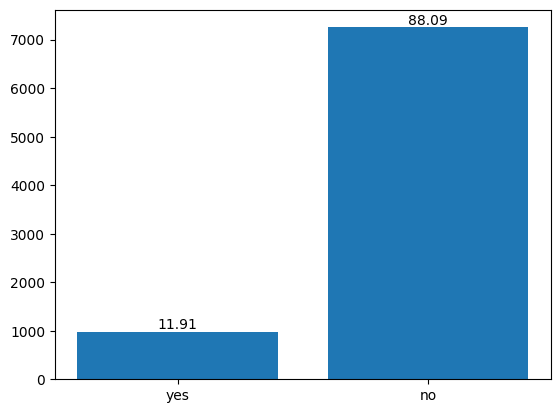

In [ ]:
target_bar_plot(y_test_pred)


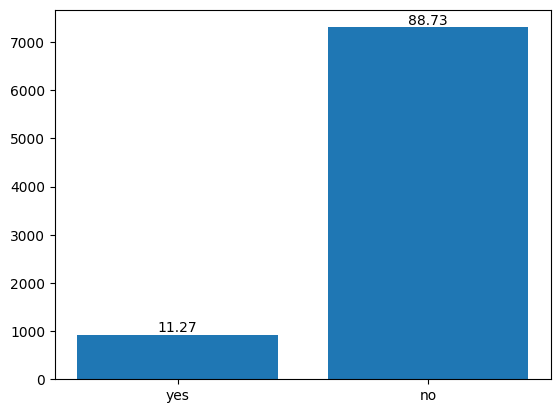

In [ ]:
target_bar_plot(y_test)

# Random Forest

In [ ]:
X_train["job"].value_counts()

job
admin.           8269
blue-collar      7440
technician       5420
services         3181
management       2340
retired          1388
entrepreneur     1159
self-employed    1114
housemaid         859
unemployed        812
student           691
unknown           267
Name: count, dtype: int64

In [ ]:
from sklearn.ensemble import RandomForestClassifier


numeric_cols1 =['age', 'duration', 'campaign', 'pdays', 'previous', 'nr.employed', 'cons.price.idx', "month_sin", "month_cos", "day_sin", "day_cos"] # symmetric
numeric_cols2 = ['emp.var.rate', 'cons.conf.idx', 'euribor3m' ] # skewed

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
passthrough_cols = ['customer_contacted', 'age', 'duration', 'campaign', 'pdays', 'previous', 'nr.employed', 'cons.price.idx', "month_sin", "month_cos", "day_sin", "day_cos", 'emp.var.rate', 'cons.conf.idx', 'euribor3m' ]

preprocessor = ColumnTransformer(transformers=[
    #('standard', StandardScaler(), numeric_cols1),
    #('min_max_scalar', MinMaxScaler(), numeric_cols2),
    ('one_hot_encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ("pass", 'passthrough', passthrough_cols)
])


pipe = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, class_weight='balanced'))
])

cross_val_score(pipe, X_train, y_train, scoring='roc_auc')
pipe.fit(X_train, y_train)
y_test_pred = (pipe.predict_proba(X_test)[:,1] > 0.5).astype('int')
y_test_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(8236,))

0.6820512820512821

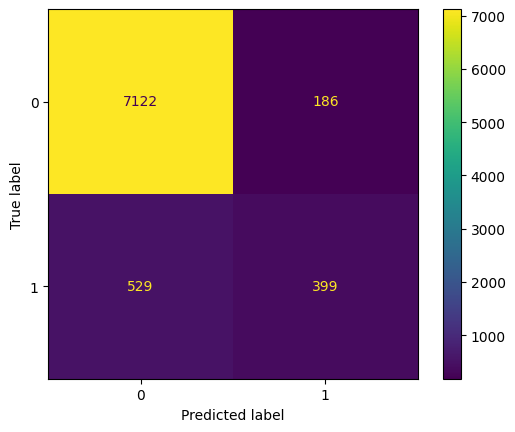

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm).plot()
precision_score(y_test, y_test_pred)

# add features


In [ ]:
def create_new_features(df):

    month_map = {
    'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
    'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12
    }

    day_map = {
        'mon':1, 'tue':2, 'wed':3, 'thu':4,
        'fri':5, 'sat':6, 'sun':7
    }

    df["customer_contacted"] = (df["pdays"] != 999).astype('int')

    df['month_num'] = df['month'].map(month_map)
    df['day_num'] = df['day_of_week'].map(day_map)

    df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

    df['day_sin'] = np.sin(2 * np.pi * df['day_num'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_num'] / 7)

    

    cleaned_df = df.drop(columns=['month', 'day_of_week', 'month_num', 'day_num'])

    return cleaned_df

cleaned_bank_df = create_new_features(bank_df)

numeric_cols = [ "month_sin", "month_cos", "day_sin", "day_cos"]
# 'pdays', 'previous',

for col in numeric_cols:
    q1, q2, q3 = quantiles(cleaned_bank_df[col])
    skb = (q1+q3-2*q2) / (q3 - q1)
    print(f"{col}: {round(skb, 3)}")
    if abs(skb) > 0.5:
        print(f"{col} is skewed\n")
    else:
        print(f"{col} is symmetric\n")


month_sin: -0.0
month_sin is symmetric

month_cos: 1.0
month_cos is skewed

day_sin: -0.428
day_sin is symmetric

day_cos: -1.0
day_cos is skewed



In [ ]:
new_bank_df = create_new_features(bank_df)

X = bank_df.drop("y", axis=1)
y = bank_df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=9)

numeric_cols1 =['age', 'duration', 'campaign', 'pdays', 'previous', 'nr.employed', 'cons.price.idx'] # "month_sin", "month_cos", "day_sin", "day_cos"] # symmetric
numeric_cols2 = ['emp.var.rate', 'cons.conf.idx', 'euribor3m' ] # skewed
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome'] #, 'month', 'day_of_week'
passthrough_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'nr.employed', 'cons.price.idx', 'emp.var.rate', 'cons.conf.idx', 'euribor3m', "month_sin", "month_cos", "day_sin", "day_cos" ]

preporcessor = ColumnTransformer(transformers=[
    ('one_hot_encode', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ("pass", 'passthrough', passthrough_cols)
])

In [ ]:
advance_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, oob_score=True, random_state=9),
    'Random Forest - Balanced': RandomForestClassifier(n_estimators=100, class_weight='balanced', oob_score=True, random_state=9),
    'Adaboost': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=9),
    'Adaboost - Balanced': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'), n_estimators=100,  random_state=9)
    #'XGBoost': xgb.
}

#fitted_pipeline = {}
for name, model in advance_models.items():
    pipe = Pipeline([('pre', preporcessor), ('model', model)])
    fitted_pipeline[name] = evaluate_model(name, pipe, X_train, y_train, X_test, y_test, results)

pd.DataFrame(results)

/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sumana/Desktop/AIML/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Train Accuracy,Test Accuracy,Mean CV Score,Train ROC-AUC,Test ROC AUC,Train PR AUC,Test PR AUC
0,Logistic Regression,0.911202,0.912093,0.933,0.736704,0.733622,0.630565,0.639726
1,L1 regularization,0.911233,0.912943,0.933,0.736133,0.735042,0.631210,0.645117
2,Decision Tree,0.969065,0.894488,0.799,0.940575,0.755217,0.835159,0.529237
3,Logistic Regression - Balanced,0.836582,0.846649,0.936,0.876392,0.887247,0.402314,0.419432
4,L1 regularization - Balanced,0.836825,0.847377,0.936,0.876176,0.888598,0.402622,0.420799
5,Decision Tree - Balanced,0.951427,0.885503,0.790,0.972630,0.793428,0.698738,0.494081
6,Random Forest,0.999970,0.914279,0.937,0.999983,0.791299,0.999731,0.616597
7,Random Forest - Balanced,0.999970,0.912458,0.938,0.999983,0.769106,0.999731,0.618016
8,Adaboost,0.821129,0.830136,0.934,0.870391,0.875590,0.380336,0.393197
9,Adaboost - Balanced,0.872890,0.878825,0.851,0.698530,0.707350,0.440351,0.463992


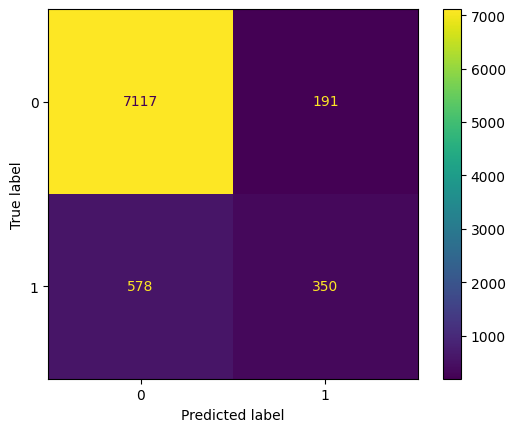

In [ ]:
cm = confusion_matrix(y_test, fitted_pipeline["Adaboost"].predict(X_test))
ConfusionMatrixDisplay(cm).plot()